# Amplitude Significance Analysis

This notebook performs formal significance checks for `A_{\phi T}` using cached amplitude products.

It computes:
- paired bootstrap confidence intervals for mean and std changes,
- paired permutation p-values,
- empirical p-values/percentiles for Planck data points vs simulation distributions.

No upstream simulation rerun is required if cache files exist.


In [7]:
import os
from pathlib import Path
import numpy as np

repo_root = Path(os.environ.get("DELENSING_REPO_ROOT", "/home3/p283342/Delensing/clean-delensing")).expanduser()
cache_dir = Path(os.environ.get("AMPLITUDE_CACHE_DIR", repo_root / "THESIS" / "cache" / "amplitude_results"))

hist_noiseless = np.load(cache_dir / "noiseless_amplitude_hist_agr2.npz", allow_pickle=True)
hist_noisy = np.load(cache_dir / "noisy_amplitude_hist_agr2.npz", allow_pickle=True)
kde_noisy = np.load(cache_dir / "noisy_amplitude_kde_agr2.npz", allow_pickle=True)

labels = [str(x) for x in hist_noiseless["labels"]]
assert labels == [str(x) for x in hist_noisy["labels"]]

print("cache_dir:", cache_dir)
print("labels:", labels)


cache_dir: /home3/p283342/Delensing/clean-delensing/THESIS/cache/amplitude_results
labels: ['MV: lensed', 'MV: internally delensed with MV-QEST', 'TT: internally delensed with Pol-QEST']


In [8]:
# Build arrays in scenario order:
# [0]=lensed, [1]=MV-QE internal delensed, [2]=Pol-QE internal delensed
A_noiseless = [hist_noiseless["a0"], hist_noiseless["a1"], hist_noiseless["a2"]]
A_noisy = [hist_noisy["a0"], hist_noisy["a1"], hist_noisy["a2"]]
A_data_noisy = np.array([kde_noisy["adata0"], kde_noisy["adata1"], kde_noisy["adata2"]], dtype=float)

n = len(A_noisy[0])
print("N simulations:", n)


N simulations: 240


## Statistical Utilities

We treat scenario comparisons as *paired* (same simulation indices across scenarios).


In [9]:
rng = np.random.default_rng(0)

def paired_bootstrap_stat(x, y, stat_fn, n_boot=20000, rng=None):
    """Bootstrap CI for stat_fn(x,y) using paired resampling of indices."""
    if rng is None:
        rng = np.random.default_rng()
    n = len(x)
    idx = rng.integers(0, n, size=(n_boot, n))
    xb = x[idx]
    yb = y[idx]
    vals = stat_fn(xb, yb)
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return vals, float(lo), float(hi)


def paired_perm_pvalue_mean_diff(x, y, n_perm=50000, rng=None):
    """Two-sided paired permutation test for mean(x-y)=0 via sign flips."""
    if rng is None:
        rng = np.random.default_rng()
    d = x - y
    obs = d.mean()
    signs = rng.choice(np.array([-1.0, 1.0]), size=(n_perm, len(d)))
    sim = (signs * d).mean(axis=1)
    p = np.mean(np.abs(sim) >= abs(obs))
    return float(obs), float(p)


def paired_perm_pvalue_std_diff(x, y, n_perm=50000, rng=None):
    """Two-sided paired permutation-style test for std(x)-std(y)."""
    if rng is None:
        rng = np.random.default_rng()
    m = 0.5 * (x + y)
    h = 0.5 * (x - y)
    obs = x.std(ddof=1) - y.std(ddof=1)
    signs = rng.choice(np.array([-1.0, 1.0]), size=(n_perm, len(x)))
    xsim = m + signs * h
    ysim = m - signs * h
    sim = xsim.std(axis=1, ddof=1) - ysim.std(axis=1, ddof=1)
    p = np.mean(np.abs(sim) >= abs(obs))
    return float(obs), float(p)


def empirical_percentile_and_p(x, x_data):
    """Percentile and two-sided empirical p-value of x_data within sample x."""
    x = np.asarray(x)
    pct = np.mean(x <= x_data)
    p_two = 2.0 * min(pct, 1.0 - pct)
    return float(pct), float(min(1.0, p_two))


## Significance: Lensed vs Delensed (Noiseless + Noisy)


In [10]:
def summarize_pair(group_name, x_lensed, x_alt, alt_name, rng):
    # mean-difference bootstrap
    stat_mean = lambda xb, yb: xb.mean(axis=1) - yb.mean(axis=1)
    vals_m, lo_m, hi_m = paired_bootstrap_stat(x_lensed, x_alt, stat_mean, n_boot=20000, rng=rng)
    mean_obs = x_lensed.mean() - x_alt.mean()

    # std-difference bootstrap
    stat_std = lambda xb, yb: xb.std(axis=1, ddof=1) - yb.std(axis=1, ddof=1)
    vals_s, lo_s, hi_s = paired_bootstrap_stat(x_lensed, x_alt, stat_std, n_boot=20000, rng=rng)
    std_obs = x_lensed.std(ddof=1) - x_alt.std(ddof=1)

    # permutation p-values
    obs_m, p_m = paired_perm_pvalue_mean_diff(x_lensed, x_alt, n_perm=50000, rng=rng)
    obs_s, p_s = paired_perm_pvalue_std_diff(x_lensed, x_alt, n_perm=50000, rng=rng)

    return {
        "group": group_name,
        "alt": alt_name,
        "mean_diff_obs": float(mean_obs),
        "mean_diff_ci95": (lo_m, hi_m),
        "mean_diff_p_perm": p_m,
        "std_diff_obs": float(std_obs),
        "std_diff_ci95": (lo_s, hi_s),
        "std_diff_p_perm": p_s,
    }

results = []
for group_name, A in [("noiseless", A_noiseless), ("noisy", A_noisy)]:
    x0 = A[0]
    results.append(summarize_pair(group_name, x0, A[1], labels[1], rng))
    results.append(summarize_pair(group_name, x0, A[2], labels[2], rng))

for r in results:
    print(" ", r["group"], "|", r["alt"], "---")
    print(f"mean(lensed-alt) = {r['mean_diff_obs']:+.4f}  CI95={r['mean_diff_ci95']}")
    print(f"perm p (mean diff) = {r['mean_diff_p_perm']:.4g}")
    print(f"std(lensed)-std(alt) = {r['std_diff_obs']:+.4f}  CI95={r['std_diff_ci95']}")
    print(f"perm p (std diff) = {r['std_diff_p_perm']:.4g}")


  noiseless | MV: internally delensed with MV-QEST ---
mean(lensed-alt) = +0.8129  CI95=(0.7908716513807351, 0.8344546816403813)
perm p (mean diff) = 0
std(lensed)-std(alt) = +0.1546  CI95=(0.1373227360050645, 0.17150189676612146)
perm p (std diff) = 0
  noiseless | TT: internally delensed with Pol-QEST ---
mean(lensed-alt) = +0.5652  CI95=(0.5427886128065555, 0.5871036309842784)
perm p (mean diff) = 0
std(lensed)-std(alt) = -0.0095  CI95=(-0.030008915621954232, 0.01103861286420378)
perm p (std diff) = 0.6238
  noisy | MV: internally delensed with MV-QEST ---
mean(lensed-alt) = +0.4738  CI95=(0.44485323269427895, 0.5024267829908151)
perm p (mean diff) = 0
std(lensed)-std(alt) = +0.1301  CI95=(0.1074214707322164, 0.15181259551891949)
perm p (std diff) = 0
  noisy | TT: internally delensed with Pol-QEST ---
mean(lensed-alt) = +0.1112  CI95=(0.07916559021847386, 0.1428515654962093)
perm p (mean diff) = 0
std(lensed)-std(alt) = -0.0346  CI95=(-0.06222706671796067, -0.0065122802208035695)
p

## Planck Data Position Within Noisy Simulation Distributions


In [11]:
for i, lab in enumerate(labels):
    pct, p2 = empirical_percentile_and_p(A_noisy[i], A_data_noisy[i])
    print(f"{lab:45s}  A_data={A_data_noisy[i]:.4f}  percentile={pct:.3f}  two-sided p={p2:.4f}")


MV: lensed                                     A_data=0.7048  percentile=0.217  two-sided p=0.4333
MV: internally delensed with MV-QEST           A_data=0.4434  percentile=0.404  two-sided p=0.8083
TT: internally delensed with Pol-QEST          A_data=0.8738  percentile=0.529  two-sided p=0.9417


## Interpretation Notes

- If `mean_diff = mean(lensed - delensed)` is positive and CI excludes 0, delensing lowers the mean amplitude.
- If `std_diff = std(lensed) - std(delensed)` is positive and CI excludes 0, delensing lowers scatter.
- Empirical Planck p-values near 0 or 1 indicate Planck lies in the distribution tail for that scenario.


## Summary Table (Readable)

This cell builds a compact table of mean/variance reductions, 95% bootstrap CIs, and permutation p-values.


In [12]:
import pandas as pd

rows = []
for r in results:
    rows.append({
        'group': r['group'],
        'comparison': f"lensed vs {r['alt']}",
        'mean_diff': r['mean_diff_obs'],
        'mean_ci95_lo': r['mean_diff_ci95'][0],
        'mean_ci95_hi': r['mean_diff_ci95'][1],
        'p_mean_perm': r['mean_diff_p_perm'],
        'std_diff': r['std_diff_obs'],
        'std_ci95_lo': r['std_diff_ci95'][0],
        'std_ci95_hi': r['std_diff_ci95'][1],
        'p_std_perm': r['std_diff_p_perm'],
    })

df = pd.DataFrame(rows)
df['mean_reduction_pct'] = 100.0 * df['mean_diff'] / np.array([A_noiseless[0].mean() if g=='noiseless' else A_noisy[0].mean() for g in df['group']])
df['std_reduction_pct'] = 100.0 * df['std_diff'] / np.array([A_noiseless[0].std(ddof=1) if g=='noiseless' else A_noisy[0].std(ddof=1) for g in df['group']])

display_cols = [
    'group','comparison',
    'mean_diff','mean_ci95_lo','mean_ci95_hi','mean_reduction_pct','p_mean_perm',
    'std_diff','std_ci95_lo','std_ci95_hi','std_reduction_pct','p_std_perm'
]

df_disp = df[display_cols].copy()
for c in ['mean_diff','mean_ci95_lo','mean_ci95_hi','std_diff','std_ci95_lo','std_ci95_hi']:
    df_disp[c] = df_disp[c].map(lambda x: f"{x:+.4f}")
for c in ['mean_reduction_pct','std_reduction_pct']:
    df_disp[c] = df_disp[c].map(lambda x: f"{x:+.1f}%")
for c in ['p_mean_perm','p_std_perm']:
    df_disp[c] = df_disp[c].map(lambda x: f"{x:.3g}")

df_disp


,group,comparison,mean_diff,mean_ci95_lo,mean_ci95_hi,mean_reduction_pct,p_mean_perm,std_diff,std_ci95_lo,std_ci95_hi,std_reduction_pct,p_std_perm
0,noiseless,lensed vs MV: internally delensed with MV-QEST,+0.8129,+0.7909,+0.8345,+82.3%,0,+0.1546,+0.1373,+0.1715,+78.1%,0
1,noiseless,lensed vs TT: internally delensed with Pol-QEST,+0.5652,+0.5428,+0.5871,+57.2%,0,-0.0095,-0.0300,+0.0110,-4.8%,0.624
2,noisy,lensed vs MV: internally delensed with MV-QEST,+0.4738,+0.4449,+0.5024,+49.4%,0,+0.1301,+0.1074,+0.1518,+43.5%,0
3,noisy,lensed vs TT: internally delensed with Pol-QEST,+0.1112,+0.0792,+0.1429,+11.6%,0,-0.0346,-0.0622,-0.0065,-11.6%,0.0188


## Figure 1: Effect Sizes With 95% CIs

Positive values indicate a reduction from lensed baseline.


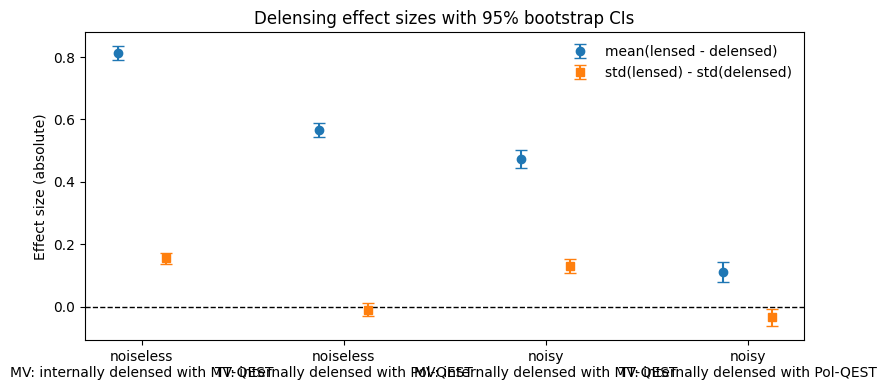

In [13]:
import matplotlib.pyplot as plt

labels_plot = [f"{r['group']}\n{r['alt']}" for r in results]
x = np.arange(len(results))

mean_y = np.array([r['mean_diff_obs'] for r in results])
mean_lo = np.array([r['mean_diff_ci95'][0] for r in results])
mean_hi = np.array([r['mean_diff_ci95'][1] for r in results])
mean_err = np.vstack([mean_y - mean_lo, mean_hi - mean_y])

std_y = np.array([r['std_diff_obs'] for r in results])
std_lo = np.array([r['std_diff_ci95'][0] for r in results])
std_hi = np.array([r['std_diff_ci95'][1] for r in results])
std_err = np.vstack([std_y - std_lo, std_hi - std_y])

fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.axhline(0, color='k', ls='--', lw=1)
ax.errorbar(x - 0.12, mean_y, yerr=mean_err, fmt='o', capsize=4, label='mean(lensed - delensed)')
ax.errorbar(x + 0.12, std_y, yerr=std_err, fmt='s', capsize=4, label='std(lensed) - std(delensed)')
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, rotation=0)
ax.set_ylabel('Effect size (absolute)')
ax.set_title('Delensing effect sizes with 95% bootstrap CIs')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Figure 2: Planck Data Position in Noisy Simulation Distributions

Bars show percentile (0 to 1); dashed lines at 0.025 and 0.975 indicate two-sided 5% tails.


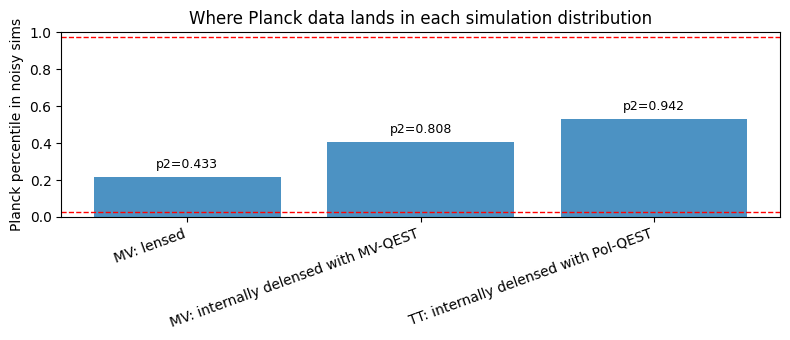

In [14]:
planck_rows = []
for i, lab in enumerate(labels):
    pct, p2 = empirical_percentile_and_p(A_noisy[i], A_data_noisy[i])
    planck_rows.append((lab, pct, p2))

fig, ax = plt.subplots(1, 1, figsize=(8, 3.5))
x = np.arange(len(planck_rows))
pcts = [r[1] for r in planck_rows]
ax.bar(x, pcts, alpha=0.8)
ax.axhline(0.025, color='r', ls='--', lw=1)
ax.axhline(0.975, color='r', ls='--', lw=1)
ax.set_xticks(x)
ax.set_xticklabels([r[0] for r in planck_rows], rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Planck percentile in noisy sims')
ax.set_title('Where Planck data lands in each simulation distribution')
for i, (_, pct, p2) in enumerate(planck_rows):
    ax.text(i, min(0.98, pct + 0.05), f"p2={p2:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()
